## 1. 📦 Install & Import Libraries

In [27]:
import os
import numpy as np
from glob import glob
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.model_selection import train_test_split

import albumentations as A #handles augmentation
from albumentations.pytorch import ToTensorV2

import matplotlib.pyplot as plt
from tqdm import tqdm

## 2. ⚙️ Configuration & Hyperparameters

Centralizing all settings in one place makes it easy to tune and experiment.

In [28]:
class CFG:
    DATA_DIR       = "/kaggle/input/datasets/briscdataset/brisc2025/brisc2025"
    TRAIN_IMG_DIR  = os.path.join(DATA_DIR, "segmentation_task/train/images")
    TRAIN_MASK_DIR = os.path.join(DATA_DIR, "segmentation_task/train/masks")
    TEST_IMG_DIR   = os.path.join(DATA_DIR, "segmentation_task/test/images")
    TEST_MASK_DIR  = os.path.join(DATA_DIR, "segmentation_task/test/masks")

    IMG_SIZE    = 256
    IN_CHANNELS = 3
    NUM_CLASSES = 1

    EPOCHS      = 40
    BATCH_SIZE  = 32      # doubled from 16 — each GPU handles 16
    LR          = 2e-4    # scale LR proportionally with batch size
    VAL_SPLIT   = 0.15
    NUM_WORKERS = 4       # increase workers too — more GPUs, more CPU feeding needed

    SAVE_PATH   = "/kaggle/working/unet_scratch.pth"
    BACKUP_PATH = "/kaggle/working/unet_checkpoint_epoch{}.pth"

## 3. 🗂️ Dataset Class

In [29]:
class BRISCDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths  = mask_paths
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image as RGB numpy array → shape (H, W, 3)
        image = np.array(Image.open(self.image_paths[idx]).convert("RGB"))

        # Load mask as grayscale → shape (H, W)
        mask = np.array(Image.open(self.mask_paths[idx]).convert("L"))

        # Binarize: any pixel brighter than 127 = tumor (1), rest = background (0)
        # We use float32 because the loss function expects float targets
        mask = (mask > 127).astype(np.float32)

        if self.transform:
            # Albumentations applies the SAME random transform to BOTH
            # image and mask — this is crucial. If you flip the image,
            # you must flip the mask the same way, or labels become wrong.
            out   = self.transform(image=image, mask=mask)
            image = out["image"]   # Tensor (3, H, W)
            mask  = out["mask"]    # Tensor (H, W)

        # Mask shape: (H, W) → (1, H, W) to match model output
        mask = mask.unsqueeze(0) if isinstance(mask, torch.Tensor) \
               else torch.tensor(mask).unsqueeze(0)

        return image, mask

## 4. 🔄 Augmentation & DataLoaders

In [30]:
train_transform = A.Compose([
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, p=0.5),
    A.RandomBrightnessContrast(p=0.4),

    # ElasticTransform warps the image like a rubber sheet.
    # Very powerful for medical images — simulates real anatomical variation.
    A.ElasticTransform(alpha=1, sigma=50, p=0.3),

    # Normalize with ImageNet stats even though we train from scratch.
    # This still helps because it centers pixel values around 0,
    # which makes gradient flow more stable early in training.
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std =(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Validation/Test: no random transforms — just resize + normalize
val_transform = A.Compose([
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std =(0.229, 0.224, 0.225)),
    ToTensorV2()
])

In [31]:
# Gather file paths
train_images = sorted(glob(os.path.join(CFG.TRAIN_IMG_DIR, "*")))
train_masks  = sorted(glob(os.path.join(CFG.TRAIN_MASK_DIR, "*")))
test_images  = sorted(glob(os.path.join(CFG.TEST_IMG_DIR, "*")))
test_masks   = sorted(glob(os.path.join(CFG.TEST_MASK_DIR, "*")))

# Hold out 15% of training data for validation
tr_imgs, vl_imgs, tr_msks, vl_msks = train_test_split(
    train_images, train_masks,
    test_size=CFG.VAL_SPLIT, random_state=SEED
)

train_ds = BRISCDataset(tr_imgs, tr_msks, transform=train_transform)
val_ds   = BRISCDataset(vl_imgs, vl_msks, transform=val_transform)
test_ds  = BRISCDataset(test_images, test_masks, transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE,
                          shuffle=True,  num_workers=CFG.NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG.BATCH_SIZE,
                          shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG.BATCH_SIZE,
                          shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True)

# Sanity check
imgs, msks = next(iter(train_loader))
print(f"Image batch shape : {imgs.shape}")   # (16, 3, 256, 256)
print(f"Mask batch shape  : {msks.shape}")   # (16, 1, 256, 256)

Image batch shape : torch.Size([32, 3, 256, 256])
Mask batch shape  : torch.Size([32, 1, 256, 256])


## 5. 🏗️ U-Net From Scratch

#### 5a. Double Convolution Block
#### Every encoder and decoder step uses this as its building block:

In [32]:
class DoubleConv(nn.Module):
    """
    The fundamental U-Net building block:
    Conv2d → BatchNorm → ReLU → Conv2d → BatchNorm → ReLU

    Why two convolutions?
    Each conv has a 3×3 receptive field. Two stacked convs give a 5×5
    effective receptive field, capturing richer spatial context than one alone.

    Why BatchNorm?
    Normalizes activations within each batch, preventing internal covariate
    shift. This makes training much more stable and allows higher learning rates.

    Why ReLU?
    Introduces non-linearity. Without it, stacking convs is mathematically
    equivalent to a single linear transform — the network can't learn complex patterns.

    padding=1 on a 3×3 kernel keeps the spatial dimensions (H, W) unchanged after the conv — 
    without it, each conv would shrink the feature map by 2 pixels on each side.
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels,
                      kernel_size=3, padding=1, bias=False),
            # bias=False because BatchNorm already has a learnable bias term
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels,
                      kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

#### 5b. Encoder Block

In [33]:
class EncoderBlock(nn.Module):
    """
    One step down the encoder:
      1. DoubleConv — learn features at current resolution
      2. MaxPool2d  — halve spatial dimensions (downsample)
      Why MaxPool and not a strided Conv? MaxPool is parameter-free, which means fewer weights to train. 
      It also explicitly keeps only the strongest activations in each 2×2 window, 
      which acts as a form of translation invariance.

    The output BEFORE pooling is the skip connection.
    The output AFTER pooling goes deeper into the network.
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        skip = self.conv(x)   # Full-resolution features → saved for skip connection
        down = self.pool(skip) # Halved-resolution features → passed deeper
        return skip, down

#### 5c. Decoder Block

In [34]:
class DecoderBlock(nn.Module):
    """
    One step up the decoder:
      1. ConvTranspose2d — learn to upsample (double spatial dimensions)
      2. Concatenate skip connection from the matching encoder block
      3. DoubleConv — fuse the upsampled features with the skip features

    The skip connection is the key: it brings back fine spatial detail
    (edges, textures) that was lost during downsampling.

    Why concat and not add?
    Concatenation preserves both feature sets independently.
    Addition assumes they represent the same thing and blends them.
    For segmentation, keeping them separate gives the decoder more
    information to work with.
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()

        # ConvTranspose2d is a learnable upsampling — the model learns
        # how to "fill in" the missing pixels rather than using a fixed
        # interpolation rule like bilinear upsampling.
        # stride=2 doubles the spatial resolution.
        self.upsample = nn.ConvTranspose2d(
            in_channels, out_channels,
            kernel_size=2, stride=2
        )

        # After concat, input channels = out_channels (from upsample)
        #                              + out_channels (from skip)
        #                              = 2 * out_channels
        self.conv = DoubleConv(out_channels * 2, out_channels)

    def forward(self, x, skip):
        x = self.upsample(x)   # Double the spatial size

        # Handle potential size mismatch due to odd input dimensions.
        # E.g., if encoder had input 257×257, after pool → 128×128,
        # after upsample → 256×256, but skip was 257×257 → mismatch.
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)

        # Concatenate along channel dimension
        # skip: (B, C, H, W) + x: (B, C, H, W) → (B, 2C, H, W)
        x = torch.cat([skip, x], dim=1)

        return self.conv(x)

#### 5d. Full U-Net

In [35]:
class UNet(nn.Module):
    """
    Full U-Net for binary segmentation.

    Architecture (features=[64, 128, 256, 512]):
      Encoder: 3 → 64 → 128 → 256 → 512
      Bottleneck:        512 → 1024
      Decoder: 1024 → 512 → 256 → 128 → 64
      Head:    64 → 1 (sigmoid applied in loss, not here)

    Total parameters: ~31 million (comparable to ResNet-34 based U-Net)
    """
    def __init__(self, in_channels=3, num_classes=1, features=[64, 128, 256, 512]):
        super().__init__()

        # --- Encoder ---
        self.encoders = nn.ModuleList()
        prev_channels = in_channels
        for f in features:
            self.encoders.append(EncoderBlock(prev_channels, f))
            prev_channels = f
        # After 4 encoder blocks: spatial size is 256/2^4 = 16×16

        # --- Bottleneck ---
        # Deepest layer — no pooling, no skip connection
        # Learns the most abstract, semantically rich features
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)
        # features[-1]*2 = 1024 channels at 16×16 spatial resolution

        # --- Decoder ---
        self.decoders = nn.ModuleList()
        prev_channels = features[-1] * 2   # Start from bottleneck output (1024)
        for f in reversed(features):
            self.decoders.append(DecoderBlock(prev_channels, f))
            prev_channels = f

        # --- Output Head ---
        # 1×1 convolution collapses 64 channels → 1 channel (tumor probability map)
        # No activation here — sigmoid is applied inside the loss function
        # (BCEWithLogitsLoss is more numerically stable than BCE + manual sigmoid)
        self.output_conv = nn.Conv2d(features[0], num_classes, kernel_size=1)

    def forward(self, x):
        # --- Encoder path: collect skip connections ---
        skips = []
        for encoder in self.encoders:
            skip, x = encoder(x)
            skips.append(skip)
        # skips = [64ch@256, 128ch@128, 256ch@64, 512ch@32]
        # x is now 512ch @ 16×16

        # --- Bottleneck ---
        x = self.bottleneck(x)
        # x is now 1024ch @ 16×16

        # --- Decoder path: use skip connections in reverse order ---
        # reversed(skips): [512@32, 256@64, 128@128, 64@256]
        for decoder, skip in zip(self.decoders, reversed(skips)):
            x = decoder(x, skip)

        # --- Output ---
        return self.output_conv(x)
        # Shape: (B, 1, 256, 256) — raw logits

In [36]:
# Instantiate model as usual
model = UNet(in_channels=CFG.IN_CHANNELS, num_classes=CFG.NUM_CLASSES)

# Check how many GPUs are available
print(f"GPUs available: {torch.cuda.device_count()}")  # Should print 2

# Wrap with DataParallel — PyTorch automatically splits each batch
# across both GPUs and merges the gradients
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

# Always move to cuda AFTER wrapping
model = model.to(DEVICE)

GPUs available: 2
Using 2 GPUs!


## 6. 📐 Loss Functions & Metrics

In [37]:
class DiceLoss(nn.Module):
    """
    Dice Loss directly optimizes the overlap between prediction and ground truth.

    Formula: DiceLoss = 1 - (2 * |P ∩ G| + smooth) / (|P| + |G| + smooth)

    Why not just BCE?
    BCE treats every pixel equally. In brain MRI, tumor pixels are maybe
    5-10% of the image. BCE can get a very low loss by predicting ALL
    background — that's 90%+ pixel accuracy but useless for diagnosis.
    Dice Loss specifically rewards correctly identifying the tumor region,
    regardless of how small it is.
    """
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        preds = torch.sigmoid(logits)   # Raw logits → probabilities

        # Flatten spatial dims: (B, 1, H, W) → (B, H*W)
        preds   = preds.view(preds.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        intersection = (preds * targets).sum(dim=1)
        dice = (2.0 * intersection + self.smooth) / \
               (preds.sum(dim=1) + targets.sum(dim=1) + self.smooth)

        return 1.0 - dice.mean()


class CombinedLoss(nn.Module):
    """
    BCE + Dice combined.
    BCE: fine-grained per-pixel correction.
    Dice: big-picture overlap optimization.
    Together they converge faster and more stably than either alone.
    """
    def __init__(self, w_bce=0.5, w_dice=0.5):
        super().__init__()
        self.w_bce  = w_bce
        self.w_dice = w_dice
        self.bce    = nn.BCEWithLogitsLoss()
        self.dice   = DiceLoss()

    def forward(self, logits, targets):
        return self.w_bce * self.bce(logits, targets) + \
               self.w_dice * self.dice(logits, targets)


def dice_score(logits, targets, threshold=0.5, smooth=1e-6):
    """
    Evaluation metric (not used for training — no gradients needed).
    Threshold 0.5: any pixel with probability > 0.5 is predicted as tumor.
    """
    preds   = (torch.sigmoid(logits) > threshold).float()
    preds   = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    inter   = (preds * targets).sum(dim=1)
    return ((2.0 * inter + smooth) /
            (preds.sum(dim=1) + targets.sum(dim=1) + smooth)).mean().item()


def iou_score(logits, targets, threshold=0.5, smooth=1e-6):
    """
    Intersection over Union — another standard segmentation metric.
    IoU = |P ∩ G| / |P ∪ G|
    Always ≤ Dice Score. Both should be reported.
    """
    preds   = (torch.sigmoid(logits) > threshold).float()
    preds   = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    inter   = (preds * targets).sum(dim=1)
    union   = preds.sum(dim=1) + targets.sum(dim=1) - inter
    return ((inter + smooth) / (union + smooth)).mean().item()


criterion = CombinedLoss()

## 7. 🚀 Training Loop

In [38]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # Activates dropout & batchnorm training behavior
    total_loss, total_dice, total_iou = 0, 0, 0

    for images, masks in tqdm(loader, desc="Train", leave=False):
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()   # Clear gradients from last step

        logits = model(images)  # Forward pass → (B, 1, H, W) raw logits
        loss   = criterion(logits, masks)

        loss.backward()         # Compute gradients via backprop

        # Gradient clipping: if gradients explode (become huge),
        # they're rescaled so their norm ≤ 1.0. Prevents instability
        # especially important when training from scratch.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()        # Update weights

        total_loss += loss.item()
        total_dice += dice_score(logits.detach(), masks)
        total_iou  += iou_score(logits.detach(), masks)

    n = len(loader)
    return total_loss / n, total_dice / n, total_iou / n


@torch.no_grad()  # Tells PyTorch: don't build computation graph — saves memory & time
def validate(model, loader, criterion, device):
    model.eval()   # Freezes batchnorm stats, disables dropout
    total_loss, total_dice, total_iou = 0, 0, 0

    for images, masks in tqdm(loader, desc="Val", leave=False):
        images, masks = images.to(device), masks.to(device)
        logits = model(images)
        total_loss += criterion(logits, masks).item()
        total_dice += dice_score(logits, masks)
        total_iou  += iou_score(logits, masks)

    n = len(loader)
    return total_loss / n, total_dice / n, total_iou / n

In [39]:
# Saving — extract the underlying model with .module
def save_checkpoint(model, optimizer, scheduler, epoch, best_dice, history, path):
    # If wrapped in DataParallel, unwrap with .module
    model_state = model.module.state_dict() \
                  if isinstance(model, nn.DataParallel) \
                  else model.state_dict()
    torch.save({
        "epoch"     : epoch,
        "model"     : model_state,
        "optimizer" : optimizer.state_dict(),
        "scheduler" : scheduler.state_dict(),
        "best_dice" : best_dice,
        "history"   : history
    }, path)


# Loading — load into base UNet, then re-wrap with DataParallel
def load_checkpoint(path, device):
    checkpoint = torch.load(path, map_location=device)

    model = UNet(in_channels=CFG.IN_CHANNELS, num_classes=CFG.NUM_CLASSES)
    model.load_state_dict(checkpoint["model"])  # No module. prefix issues

    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)

    model = model.to(device)
    return model, checkpoint

In [40]:
# Optimizer & Scheduler
optimizer = Adam(model.parameters(), lr=CFG.LR, weight_decay=1e-5)
# weight_decay adds L2 regularization — penalizes large weights, reduces overfitting

# Cosine Annealing: LR starts at CFG.LR and smoothly decays to 1e-6
# This lets the model make big updates early and fine-tune carefully later
scheduler = CosineAnnealingLR(optimizer, T_max=CFG.EPOCHS, eta_min=1e-6)

history = {"train_loss":[], "val_loss":[],
           "train_dice":[], "val_dice":[],
           "train_iou" :[], "val_iou" :[]}

best_dice = 0.0
history = {"train_loss":[], "val_loss":[],
           "train_dice":[], "val_dice":[],
           "train_iou" :[], "val_iou" :[]}

print(f"{'Epoch':>5} | {'TrLoss':>7} | {'TrDice':>7} | {'VlLoss':>7} | {'VlDice':>7} | {'VlIoU':>6}")
print("-" * 55)

for epoch in range(1, CFG.EPOCHS + 1):
    tr_loss, tr_dice, tr_iou = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    vl_loss, vl_dice, vl_iou = validate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    for k, v in zip(history, [tr_loss, vl_loss, tr_dice, vl_dice, tr_iou, vl_iou]):
        history[k].append(v)

    if vl_dice > best_dice:
        best_dice = vl_dice
        save_checkpoint(model, optimizer, scheduler,
                        epoch, best_dice, history, CFG.SAVE_PATH)
        tag = " ✅"
    else:
        tag = ""

    if epoch % 5 == 0:
        save_checkpoint(model, optimizer, scheduler,
                        epoch, best_dice, history,
                        CFG.BACKUP_PATH.format(epoch))
        print(f"  💾 Backup saved at epoch {epoch}")

    print(f"{epoch:>5} | {tr_loss:>7.4f} | {tr_dice:>7.4f} | {vl_loss:>7.4f} | {vl_dice:>7.4f} | {vl_iou:>6.4f}{tag}")

print(f"\nBest Validation Dice: {best_dice:.4f}")

Epoch |  TrLoss |  TrDice |  VlLoss |  VlDice |  VlIoU
-------------------------------------------------------


    1 |  0.6835 |  0.0851 |  0.6274 |  0.2296 | 0.1699 ✅


    2 |  0.5975 |  0.3094 |  0.5556 |  0.4891 | 0.3796 ✅


    3 |  0.5357 |  0.4934 |  0.5057 |  0.5313 | 0.4141 ✅


    4 |  0.4834 |  0.5665 |  0.4690 |  0.5136 | 0.3860


...

   36 |  0.0827 |  0.8655 |  0.0930 |  0.8464 | 0.7692


   37 |  0.0829 |  0.8648 |  0.0920 |  0.8487 | 0.7714 ✅


   38 |  0.0829 |  0.8649 |  0.0925 |  0.8470 | 0.7698


   39 |  0.0829 |  0.8649 |  0.0925 |  0.8470 | 0.7702


  💾 Backup saved at epoch 40
   40 |  0.0807 |  0.8691 |  0.0924 |  0.8471 | 0.7702

Best Validation Dice: 0.8487


## 8. 📊 Plot Training Curves

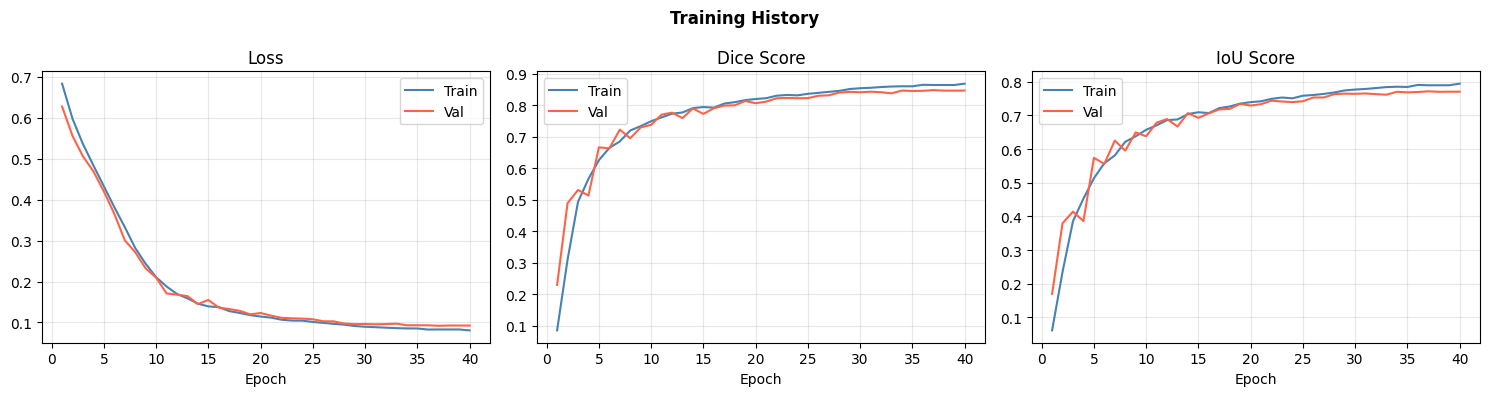

In [45]:
epochs = range(1, CFG.EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Training History", fontweight="bold")

for ax, (tr_key, vl_key), title in zip(
    axes,
    [("train_loss","val_loss"), ("train_dice","val_dice"), ("train_iou","val_iou")],
    ["Loss", "Dice Score", "IoU Score"]
):
    ax.plot(epochs, history[tr_key], label="Train", color="steelblue")
    ax.plot(epochs, history[vl_key], label="Val",   color="tomato")
    ax.set_title(title); ax.set_xlabel("Epoch")
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150)
plt.show()

## 9. 🧪 Test Evaluation & Visualization

In [46]:
# Load the raw checkpoint file
checkpoint = torch.load(CFG.SAVE_PATH, map_location=DEVICE)

# If saved as a full checkpoint dict (with epoch, optimizer etc.)
# extract just the model weights
if "model" in checkpoint:
    state_dict = checkpoint["model"]
else:
    state_dict = checkpoint  # saved with just model.state_dict()

# Remove the "module." prefix that DataParallel adds
# "module.encoders.0.conv..." → "encoders.0.conv..."
cleaned_state_dict = {
    k.replace("module.", ""): v
    for k, v in state_dict.items()
}

# Load into a plain UNet (no DataParallel needed for inference)
model = UNet(in_channels=CFG.IN_CHANNELS, num_classes=CFG.NUM_CLASSES).to(DEVICE)
model.load_state_dict(cleaned_state_dict)

print("Model loaded successfully!")

# Evaluate
ts_loss, ts_dice, ts_iou = validate(model, test_loader, criterion, DEVICE)
print(f"Test Loss : {ts_loss:.4f}")
print(f"Test Dice : {ts_dice:.4f}")
print(f"Test IoU  : {ts_iou:.4f}")

Model loaded successfully!


Test Loss : 0.0858
Test Dice : 0.8604
Test IoU  : 0.7873


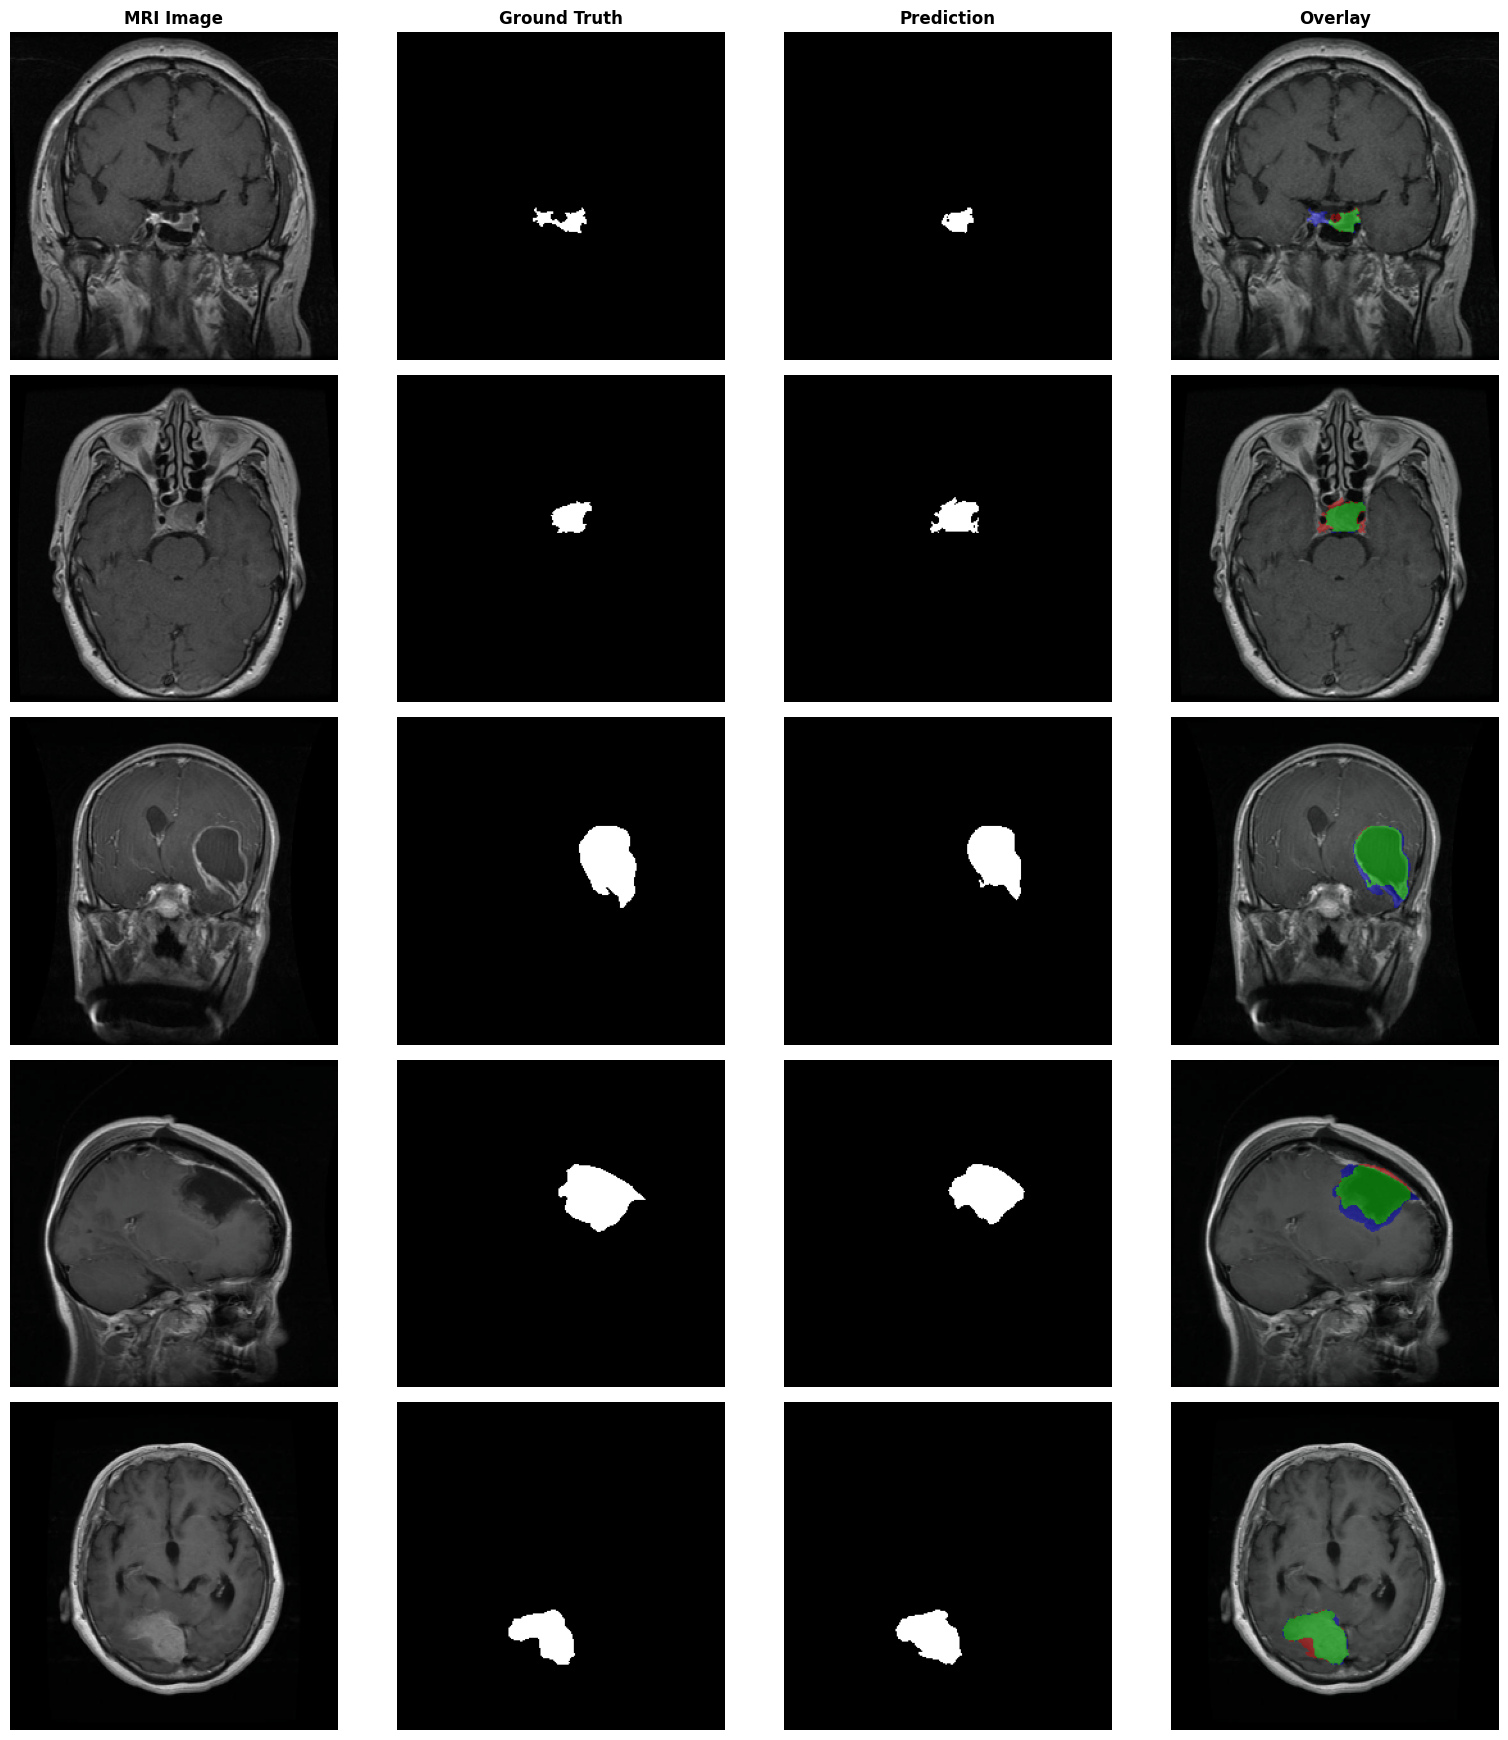

🟢 True Positive  🔴 False Positive  🔵 False Negative


In [47]:
@torch.no_grad()
def visualize_predictions(model, dataset, device, n=5):
    model.eval()
    indices = np.random.choice(len(dataset), n, replace=False)

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    fig, axes = plt.subplots(n, 4, figsize=(16, n * 3.5))
    for col, title in enumerate(["MRI Image", "Ground Truth", "Prediction", "Overlay"]):
        axes[0, col].set_title(title, fontweight="bold")

    for row, idx in enumerate(indices):
        img_t, msk_t = dataset[idx]

        logit = model(img_t.unsqueeze(0).to(device))
        pred  = (torch.sigmoid(logit) > 0.5).squeeze().cpu().numpy()

        # Denormalize for display
        img_np = img_t.permute(1,2,0).numpy()
        img_np = (img_np * std + mean).clip(0, 1)
        img_u8 = (img_np * 255).astype(np.uint8)

        gt = msk_t.squeeze().numpy()

        # Color-coded overlay:
        # Green = True Positive (correctly found tumor)
        # Red   = False Positive (predicted tumor where there's none)
        # Blue  = False Negative (missed actual tumor)
        overlay = img_u8.copy()
        overlay[(pred==1) & (gt==1)] = [0, 200, 0]
        overlay[(pred==1) & (gt==0)] = [200, 0, 0]
        overlay[(pred==0) & (gt==1)] = [0, 0, 200]

        import cv2
        overlay = cv2.addWeighted(img_u8, 0.5, overlay, 0.5, 0)

        inter = (pred * gt).sum()
        s_dice = (2*inter + 1e-6) / (pred.sum() + gt.sum() + 1e-6)

        axes[row,0].imshow(img_np)
        axes[row,1].imshow(gt, cmap="gray")
        axes[row,2].imshow(pred, cmap="gray")
        axes[row,3].imshow(overlay)
        axes[row,3].set_xlabel(f"Dice: {s_dice:.3f}", fontsize=9)

        for ax in axes[row]: ax.axis("off")

    plt.tight_layout()
    plt.savefig("/kaggle/working/predictions.png", dpi=150)
    plt.show()
    print("🟢 True Positive  🔴 False Positive  🔵 False Negative")

visualize_predictions(model, test_ds, DEVICE, n=5)

Testing: 100%|██████████| 27/27 [00:15<00:00,  1.78it/s]


Test Loss : 0.0858
Test Dice : 0.8604
Test IoU  : 0.7873


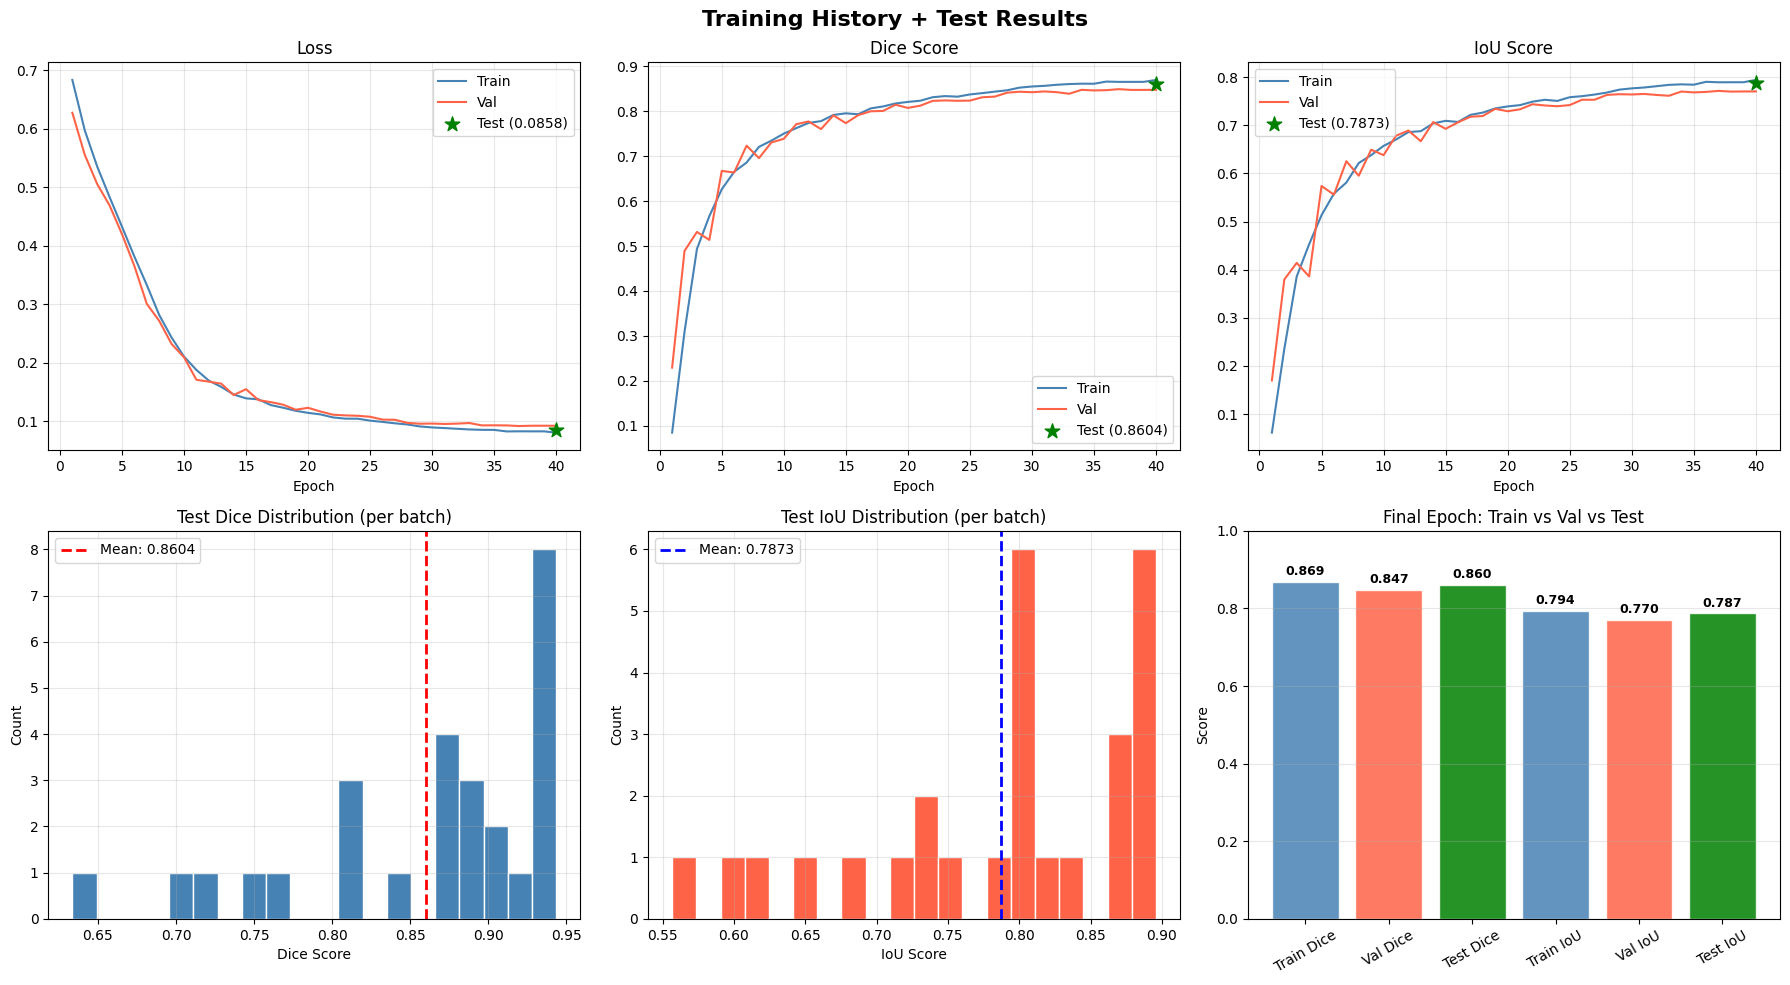

In [48]:
@torch.no_grad()
def evaluate_and_plot(model, test_loader, criterion, history, device):
    model.eval()
    total_loss, total_dice, total_iou = 0, 0, 0
    all_dice, all_iou = [], []   # per-batch scores for distribution plot

    for images, masks in tqdm(test_loader, desc="Testing"):
        images, masks = images.to(device), masks.to(device)
        logits = model(images)

        total_loss += criterion(logits, masks).item()
        
        # Track per-batch metrics to plot their distribution
        b_dice = dice_score(logits, masks)
        b_iou  = iou_score(logits, masks)
        all_dice.append(b_dice)
        all_iou.append(b_iou)

        total_dice += b_dice
        total_iou  += b_iou

    n = len(test_loader)
    ts_loss = total_loss / n
    ts_dice = total_dice / n
    ts_iou  = total_iou  / n

    print(f"Test Loss : {ts_loss:.4f}")
    print(f"Test Dice : {ts_dice:.4f}")
    print(f"Test IoU  : {ts_iou:.4f}")

    # ── Plot ──────────────────────────────────────────────────────────
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Training History + Test Results", fontsize=16, fontweight="bold")

    # ── Row 1: Training curves with test point overlaid ───────────────

    # Loss curve
    axes[0,0].plot(epochs, history["train_loss"], label="Train", color="steelblue")
    axes[0,0].plot(epochs, history["val_loss"],   label="Val",   color="tomato")
    axes[0,0].scatter(len(epochs), ts_loss, color="green", zorder=5,
                      s=120, label=f"Test ({ts_loss:.4f})", marker="*")
    axes[0,0].set_title("Loss");  axes[0,0].set_xlabel("Epoch")
    axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

    # Dice curve
    axes[0,1].plot(epochs, history["train_dice"], label="Train", color="steelblue")
    axes[0,1].plot(epochs, history["val_dice"],   label="Val",   color="tomato")
    axes[0,1].scatter(len(epochs), ts_dice, color="green", zorder=5,
                      s=120, label=f"Test ({ts_dice:.4f})", marker="*")
    axes[0,1].set_title("Dice Score"); axes[0,1].set_xlabel("Epoch")
    axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

    # IoU curve
    axes[0,2].plot(epochs, history["train_iou"], label="Train", color="steelblue")
    axes[0,2].plot(epochs, history["val_iou"],   label="Val",   color="tomato")
    axes[0,2].scatter(len(epochs), ts_iou, color="green", zorder=5,
                      s=120, label=f"Test ({ts_iou:.4f})", marker="*")
    axes[0,2].set_title("IoU Score"); axes[0,2].set_xlabel("Epoch")
    axes[0,2].legend(); axes[0,2].grid(alpha=0.3)

    # ── Row 2: Test-specific plots ─────────────────────────────────────

    # Dice distribution across test batches
    axes[1,0].hist(all_dice, bins=20, color="steelblue", edgecolor="white")
    axes[1,0].axvline(ts_dice, color="red", linestyle="--", linewidth=2,
                      label=f"Mean: {ts_dice:.4f}")
    axes[1,0].set_title("Test Dice Distribution (per batch)")
    axes[1,0].set_xlabel("Dice Score"); axes[1,0].set_ylabel("Count")
    axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

    # IoU distribution across test batches
    axes[1,1].hist(all_iou, bins=20, color="tomato", edgecolor="white")
    axes[1,1].axvline(ts_iou, color="blue", linestyle="--", linewidth=2,
                      label=f"Mean: {ts_iou:.4f}")
    axes[1,1].set_title("Test IoU Distribution (per batch)")
    axes[1,1].set_xlabel("IoU Score"); axes[1,1].set_ylabel("Count")
    axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

    # Summary bar chart: Train vs Val vs Test for final epoch
    axes[1,2].bar(
        ["Train Dice", "Val Dice", "Test Dice",
         "Train IoU",  "Val IoU",  "Test IoU"],
        [history["train_dice"][-1], history["val_dice"][-1], ts_dice,
         history["train_iou"][-1],  history["val_iou"][-1],  ts_iou],
        color=["steelblue","tomato","green",
               "steelblue","tomato","green"],
        edgecolor="white", alpha=0.85
    )
    axes[1,2].set_title("Final Epoch: Train vs Val vs Test")
    axes[1,2].set_ylabel("Score")
    axes[1,2].set_ylim(0, 1)
    axes[1,2].tick_params(axis="x", rotation=30)
    axes[1,2].grid(axis="y", alpha=0.3)

    # Annotate bars with values
    for bar in axes[1,2].patches:
        axes[1,2].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold"
        )

    plt.tight_layout()
    plt.savefig("/kaggle/working/full_results.png", dpi=150, bbox_inches="tight")
    plt.show()

    return ts_loss, ts_dice, ts_iou


ts_loss, ts_dice, ts_iou = evaluate_and_plot(model, test_loader, criterion, history, DEVICE)